<a href="https://colab.research.google.com/github/Dreamingdreamers/multimodal-emotion-recognition/blob/main/notebooks/02_text_isear_distilbert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
{
 "cells": [],
 "metadata": {},
 "nbformat": 4,
 "nbformat_minor": 2
}

{'cells': [], 'metadata': {}, 'nbformat': 4, 'nbformat_minor': 2}

In [6]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
        roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
        )
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DRIVE_PATH = '/content/drive/MyDrive/Multimodal_Emotion_Project'
ISEAR_CSV_PATH = f'{DRIVE_PATH}/data/raw/isear/isear.csv'
PROCESSED_PATH = f'{DRIVE_PATH}/data/processed'
MODEL_PATH = f'{DRIVE_PATH}/models/text_distilbert'

In [4]:
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)


In [7]:
# 3. Load & Preprocess ISEAR Dataset
df = pd.read_csv(ISEAR_CSV_PATH)

Loaded 7102 text records across 4 classes: ['anger', 'fear', 'joy', 'sadness']


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


     TEXT DISTILBERT PERFORMANCE METRICS   
1. Accuracy         : 88.53%
2. Precision (Macro): 0.8917
3. Recall (Macro)   : 0.8818
4. F1-Score (Macro) : 0.8854
5. AUC-ROC (Macro)  : 0.9801

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.91      0.90       340
        fear       0.84      0.90      0.87       451
         joy       0.94      0.92      0.93       323
     sadness       0.90      0.79      0.84       307

    accuracy                           0.89      1421
   macro avg       0.89      0.88      0.89      1421
weighted avg       0.89      0.89      0.88      1421



/tmp/ipykernel_2108/1528270205.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_labels)


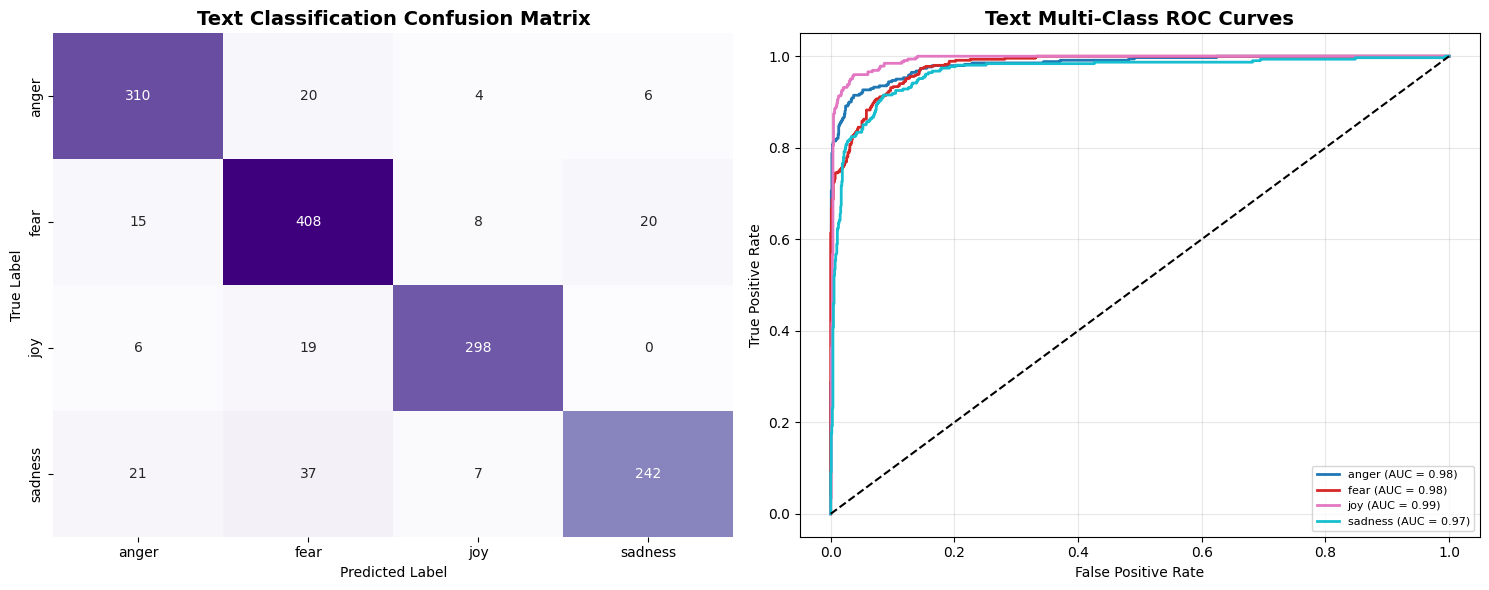

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Text artifacts saved successfully to Drive!


In [8]:
# Identify text and label columns dynamically
text_col = [col for col in df.columns if any(k in col.lower() for k in ['text', 'field', 'sit', 'content'])][0]
label_col = [col for col in df.columns if any(k in col.lower() for k in ['label', 'field1', 'emotion', 'sentiment'])][0]

df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']

# Encode emotion text labels into contiguous integers
label_mapping = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
df['label_id'] = df['label'].map(label_mapping)
# Initialize `num_labels` and `target_names` variables, so they are available when used later in the cell.
num_labels = len(df['label'].unique())
target_names = sorted(df['label'].unique())

print(f"Loaded {len(df)} text records across {num_labels} classes: {target_names}")

# 4. Train-Test Split (80/20 Stratified)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_id'])

# 5. Tokenization via HuggingFace DistilBERT Tokenizer
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

train_ds = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
test_ds = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)




train_ds = train_ds.rename_column("label_id", "labels")
test_ds = test_ds.rename_column("label_id", "labels")

# Remove extraneous columns that are not needed for model training
train_ds = train_ds.remove_columns(['text', 'label', '__index_level_0__'])
test_ds = test_ds.remove_columns(['text', 'label', '__index_level_0__'])

# 6. Initialize Pre-trained Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# 7. Fine-Tuning Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    learning_rate=3e-5,
    weight_decay=0.01,
    fp16=False, # Temporarily set to False to debug TypeError
    load_best_model_at_end=True,
    logging_steps=50
)
def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        acc = accuracy_score(labels, preds)
        return {"accuracy": acc}

trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_ds,
      eval_dataset=test_ds,
      compute_metrics=compute_metrics,
)

print("\nStarting DistilBERT fine-tuning on ISEAR dataset...")
trainer.train()

# 8. Evaluation & Metric Visualization
predictions = trainer.predict(test_ds)
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
preds = np.argmax(probs, axis=1)
y_true = np.array(test_ds['labels'])

acc = accuracy_score(y_true, preds)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average='macro')
auc_roc = roc_auc_score(y_true, probs, multi_class='ovr', average='macro')

print("\n==========================================")
print("     TEXT DISTILBERT PERFORMANCE METRICS   ")
print("==========================================")
print(f"1. Accuracy         : {acc * 100:.2f}%")
print(f"2. Precision (Macro): {precision:.4f}")
print(f"3. Recall (Macro)   : {recall:.4f}")
print(f"4. F1-Score (Macro) : {f1:.4f}")
print(f"5. AUC-ROC (Macro)  : {auc_roc:.4f}")
print("==========================================\n")

print("Detailed Classification Report:")
print(classification_report(y_true, preds, target_names=target_names))

# Plot Confusion Matrix and ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=target_names, yticklabels=target_names, ax=axes[0], cbar=False)
axes[0].set_title('Text Classification Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

colors = plt.cm.get_cmap('tab10', num_labels)
for i in range(num_labels):
    y_binary = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, probs[:, i])
    roc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=colors(i), lw=2, label=f'{target_names[i]} (AUC = {roc_val:.2f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_title('Text Multi-Class ROC Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Save Artifacts for Late Fusion
np.save(os.path.join(PROCESSED_PATH, 'text_test_probs.npy'), probs)
np.save(os.path.join(PROCESSED_PATH, 'text_test_labels.npy'), y_true)
model.save_pretrained(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)
fig.savefig(os.path.join(PROCESSED_PATH, 'text_evaluation_plots.png'), dpi=300)

print("\nText artifacts saved successfully to Drive!")

In [ ]:
print("\nInspecting the first entry of train_ds:")
first_train_entry = train_ds[0]

for key, value in first_train_entry.items():
    if key == 'input_ids':
        print(f"{key}: {value[:10]}... (truncated)") # Print first 10 tokens
        print(f"Decoded text: {tokenizer.decode(value)}")
    elif key == 'attention_mask':
        print(f"{key}: {value[:10]}... (truncated)") # Print first 10 values
    else:
        print(f"{key}: {value}")


Inspecting the first entry of train_ds:
text: I envy ice, at least if you give it warmth it melts #TaylorLautner #Twilight #hilarious #quote
label: joy
labels: 2
__index_level_0__: 2365
input_ids: [101, 1045, 21103, 3256, 1010, 2012, 2560, 2065, 2017, 2507]... (truncated)
Decoded text: [CLS] i envy ice, at least if you give it warmth it melts # taylorlautner # twilight # hilarious # quote [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [